<a href="https://colab.research.google.com/github/SithmiDesilva/Hallucination-Aware-AI-Framework-for-Trustworthy-Supply-Chain-Decision-Intelligence.-/blob/M5_Forecasting_Preprocessing/Forecasting_Sales_Train_Validation_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================================
# NOTEBOOK 2: SALES TRAIN VALIDATION DATASET PREPROCESSING
# ============================================================================
# This notebook handles the sales_train_validation.csv dataset
# It performs preprocessing, outlier detection, and data quality checks
# ============================================================================

Mounted at /content/drive


### SECTION 1: SETUP AND DATA LOADING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load the sales validation dataset
sales_val = pd.read_csv('/content/drive/MyDrive/IRP/M5 Forecasting dataset/sales_train_validation.csv')

In [5]:
print("=" * 80)
print("SALES TRAIN VALIDATION DATASET - INITIAL EXPLORATION")
print("=" * 80)
print(f"\nDataset Shape: {sales_val.shape}")
print(f"Number of rows (item-store combinations): {sales_val.shape[0]}")
print(f"Number of columns (metadata + days): {sales_val.shape[1]}")

SALES TRAIN VALIDATION DATASET - INITIAL EXPLORATION

Dataset Shape: (30490, 1919)
Number of rows (item-store combinations): 30490
Number of columns (metadata + days): 1919


### SECTION 2: INITIAL DATA EXPLORATION (BEFORE PREPROCESSING)

In [6]:
# 2.1 Basic info
print("\n--- Dataset Info ---")
print(f"Columns: {sales_val.columns[:10].tolist()} ... {sales_val.columns[-5:].tolist()}")


--- Dataset Info ---
Columns: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4'] ... ['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']


In [7]:
# 2.2 Identify day columns
day_cols = [col for col in sales_val.columns if col.startswith('d_')]
print(f"\nNumber of day columns: {len(day_cols)}")
print(f"Day range: d_1 to d_{len(day_cols)}")


Number of day columns: 1913
Day range: d_1 to d_1913


In [8]:
# 2.3 Check unique values in metadata columns
print("\n--- Unique Values in Metadata Columns ---")
print(f"Categories: {sales_val['cat_id'].unique().tolist()}")
print(f"Departments: {sales_val['dept_id'].unique().tolist()}")
print(f"States: {sales_val['state_id'].unique().tolist()}")
print(f"Stores: {sales_val['store_id'].unique().tolist()}")


--- Unique Values in Metadata Columns ---
Categories: ['HOBBIES', 'HOUSEHOLD', 'FOODS']
Departments: ['HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2', 'FOODS_1', 'FOODS_2', 'FOODS_3']
States: ['CA', 'TX', 'WI']
Stores: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']


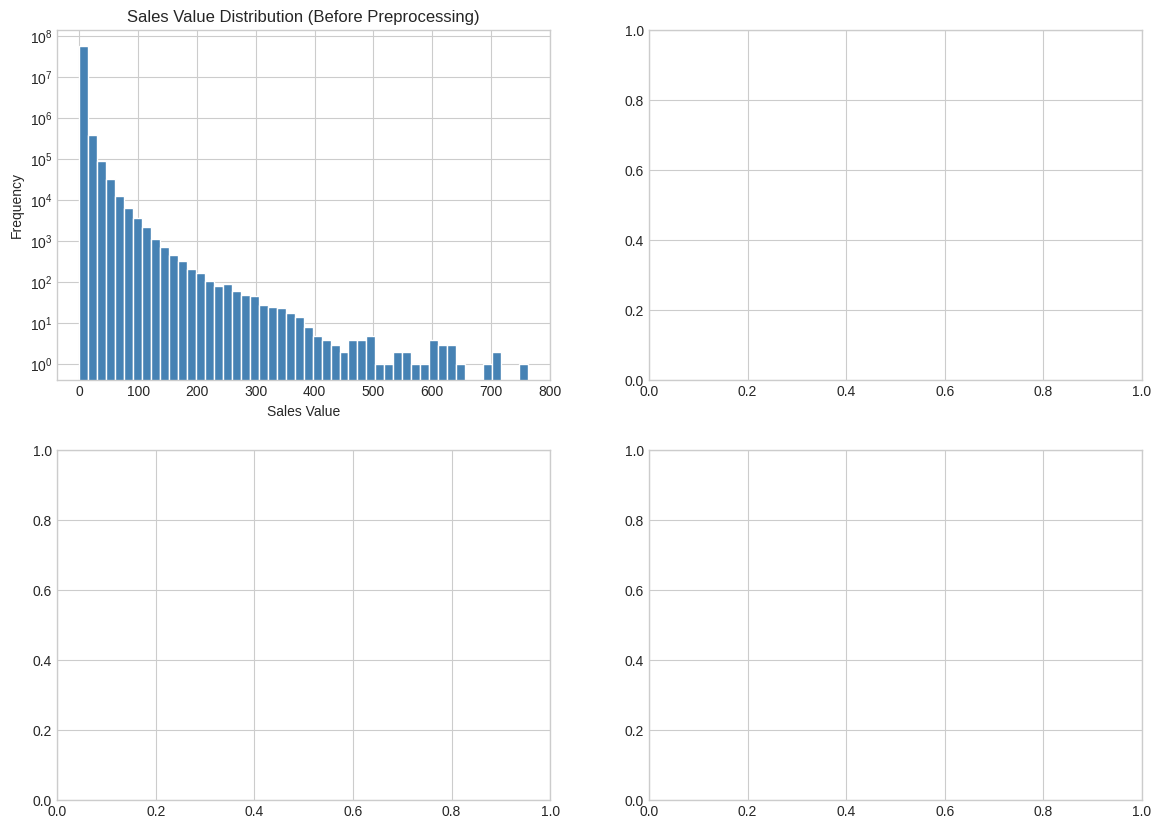

In [9]:
# 2.4 Visualize sales distribution before preprocessing
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sales value distribution (sample)
sample_sales = sales_val[day_cols].values.flatten()
sample_sales = sample_sales[~np.isnan(sample_sales)]

axes[0, 0].hist(sample_sales, bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_xlabel('Sales Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Sales Value Distribution (Before Preprocessing)')
axes[0, 0].set_yscale('log')

In [10]:
# Category distribution
cat_counts = sales_val['cat_id'].value_counts()
axes[0, 1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%')
axes[0, 1].set_title('Category Distribution')

Text(0.5, 1.0, 'Category Distribution')

In [11]:
# State distribution
state_counts = sales_val['state_id'].value_counts()
axes[1, 0].bar(state_counts.index, state_counts.values, color=['gold', 'orange', 'darkorange'])
axes[1, 0].set_xlabel('State')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('State Distribution')

Text(0.5, 1.0, 'State Distribution')

In [12]:
# Sales over time (average)
daily_avg = sales_val[day_cols].mean()
axes[1, 1].plot(range(len(daily_avg)), daily_avg.values, color='green', linewidth=0.5)
axes[1, 1].set_xlabel('Day Index')
axes[1, 1].set_ylabel('Average Sales')
axes[1, 1].set_title('Average Sales Over Time (Before Preprocessing)')

plt.tight_layout()
plt.savefig('sales_val_before_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1200x600 with 0 Axes>

### SECTION 3: PREPROCESSING

In [13]:
# Create copy for preprocessing
sales_val_processed = sales_val.copy()

In [14]:
# 3.1 Split ID column
print("\n--- Step 1: Splitting ID Column ---")
id_parts = sales_val_processed['id'].str.split('_', expand=True)
id_parts.columns = ['cat_id', 'dept_id', 'item_id', 'state_id', 'store_id', 'data_type']

# Drop original metadata columns and concatenate new ones
sales_val_processed = sales_val_processed.drop(columns=['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'])
sales_val_processed = pd.concat([sales_val_processed, id_parts], axis=1)

print("ID components extracted: cat_id, dept_id, item_id, state_id, store_id, data_type")
print(f"New shape: {sales_val_processed.shape}")


--- Step 1: Splitting ID Column ---
ID components extracted: cat_id, dept_id, item_id, state_id, store_id, data_type
New shape: (30490, 1920)


In [15]:
# 3.2 Convert to categorical types
print("\n--- Step 2: Type Conversion ---")
categorical_cols = ['cat_id', 'dept_id', 'state_id', 'store_id', 'item_id']
for col in categorical_cols:
    sales_val_processed[col] = sales_val_processed[col].astype('category')
    print(f"  {col}: {sales_val_processed[col].dtype} ({len(sales_val_processed[col].cat.categories)} categories)")


--- Step 2: Type Conversion ---
  cat_id: category (3 categories)
  dept_id: category (3 categories)
  state_id: category (3 categories)
  store_id: category (4 categories)
  item_id: category (824 categories)


In [16]:
# 3.3 Convert day columns to numeric
print("\n--- Step 3: Day Column Conversion ---")
for col in day_cols:
    sales_val_processed[col] = pd.to_numeric(sales_val_processed[col], errors='coerce')

# Convert to int16 for memory efficiency
for col in day_cols:
    sales_val_processed[col] = sales_val_processed[col].astype('int16')

print(f"Day columns converted to int16")


--- Step 3: Day Column Conversion ---
Day columns converted to int16


In [17]:
# 3.4 Calculate summary statistics
print("\n--- Step 4: Summary Statistics ---")
summary_stats = pd.DataFrame({
    'total_sales': sales_val_processed[day_cols].sum(axis=1),
    'mean_sales': sales_val_processed[day_cols].mean(axis=1),
    'std_sales': sales_val_processed[day_cols].std(axis=1),
    'min_sales': sales_val_processed[day_cols].min(axis=1),
    'max_sales': sales_val_processed[day_cols].max(axis=1),
    'zero_days': (sales_val_processed[day_cols] == 0).sum(axis=1),
    'non_zero_days': (sales_val_processed[day_cols] > 0).sum(axis=1),
    'zero_ratio': (sales_val_processed[day_cols] == 0).sum(axis=1) / len(day_cols)
})

sales_val_processed = pd.concat([sales_val_processed, summary_stats], axis=1)
print("Summary statistics added: total_sales, mean_sales, std_sales, min_sales, max_sales, zero_days, non_zero_days, zero_ratio")


--- Step 4: Summary Statistics ---
Summary statistics added: total_sales, mean_sales, std_sales, min_sales, max_sales, zero_days, non_zero_days, zero_ratio


### SECTION 4: OUTLIER DETECTION AND HANDLING

In [22]:
def detect_sales_outliers(df, day_cols, name):
    """Detect and handle outliers in sales data"""
    df_clean = df.copy()

    print(f"\n{name.upper()} OUTLIER DETECTION")
    print("=" * 60)

    # 1. IQR Method
    print("\n1. IQR Method Outlier Detection")
    print("-" * 40)

    total_outliers = 0
    outlier_days = 0

    for col in day_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR

        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]

        if len(outliers) > 0:
            total_outliers += len(outliers)
            outlier_days += 1
            df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

    print(f"  Days with outliers: {outlier_days}")
    print(f"  Total outliers capped: {total_outliers}")
    print(f"  Percentage: {total_outliers/(len(df_clean)*len(day_cols))*100:.4f}%")

    # 2. Negative Sales Check
    print("\n2. Negative Sales Check")
    print("-" * 40)
    negative_count = (df_clean[day_cols] < 0).sum().sum()
    if negative_count > 0:
        print(f"  ⚠️ Found {negative_count} negative values")
        df_clean[day_cols] = df_clean[day_cols].clip(lower=0)
        print("  ✅ Replaced negative values with 0")
    else:
        print("  ✅ No negative sales detected")

    # 3. Constant Value Detection
    print("\n3. Constant Value Detection")
    print("-" * 40)
    unique_counts = df_clean[day_cols].nunique(axis=1)
    constant_rows = (unique_counts == 1).sum()
    print(f"  Rows with constant values: {constant_rows}")

    # 4. Add outlier flag
    df_clean['outlier_flag'] = 0

    return df_clean

sales_val_cleaned = detect_sales_outliers(sales_val_processed, day_cols, 'validation')


VALIDATION OUTLIER DETECTION

1. IQR Method Outlier Detection
----------------------------------------
  Days with outliers: 1913
  Total outliers capped: 5391272
  Percentage: 9.2431%

2. Negative Sales Check
----------------------------------------
  ✅ No negative sales detected

3. Constant Value Detection
----------------------------------------
  Rows with constant values: 1


### SECTION 5: VISUALIZATION AFTER PREPROCESSING

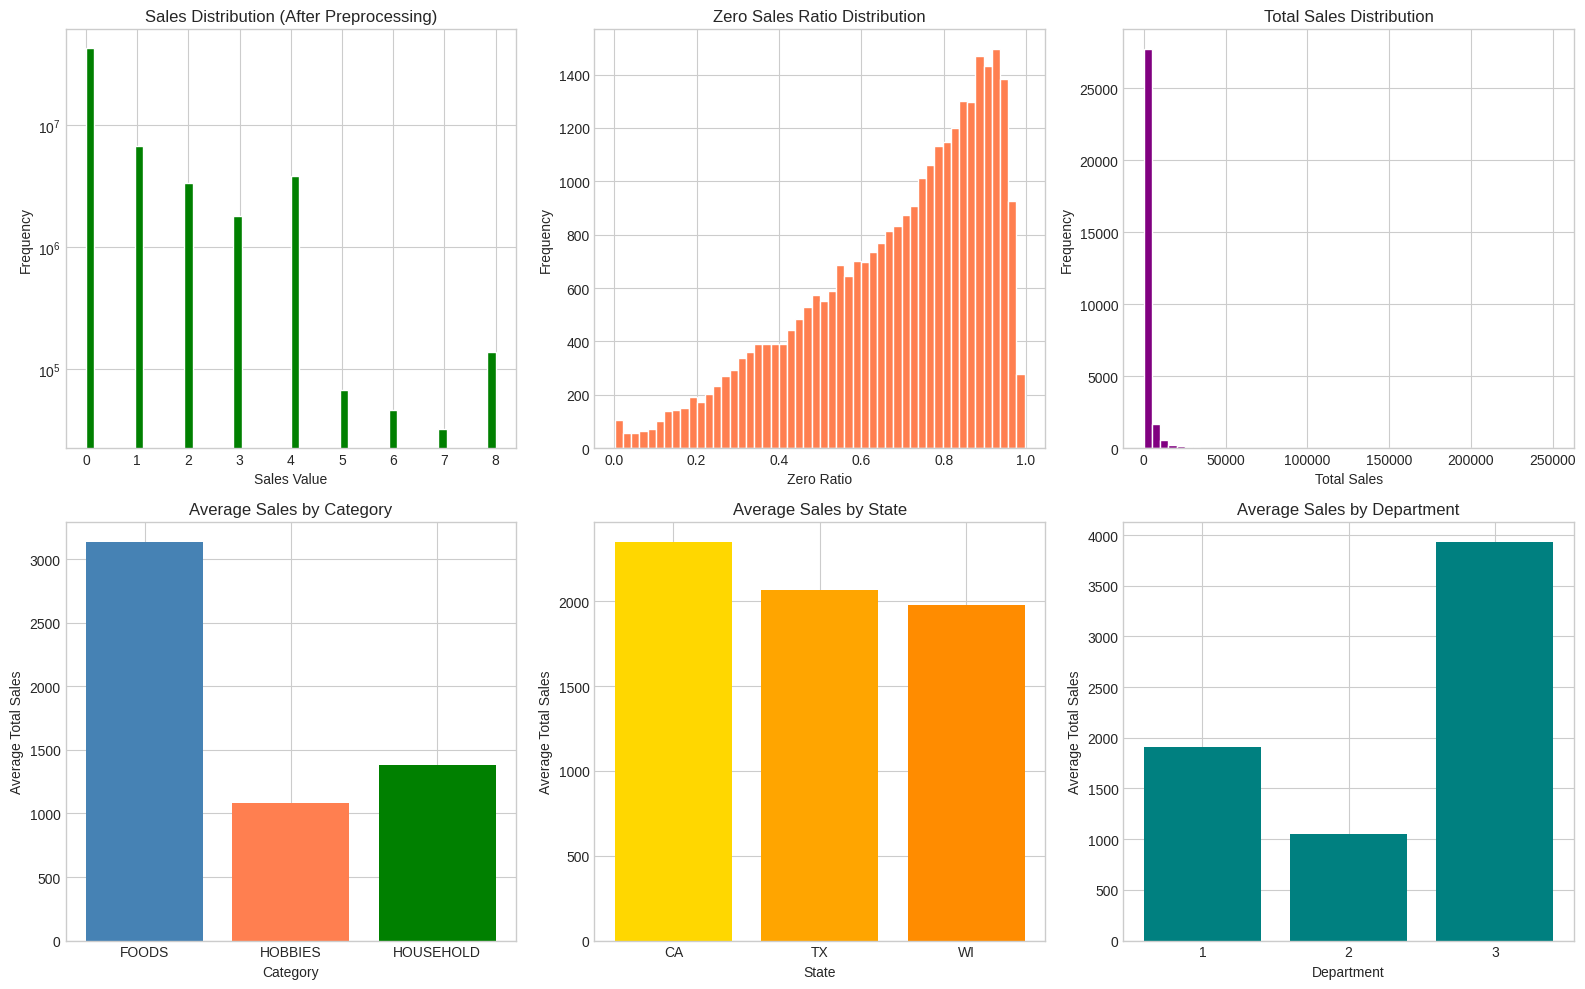

In [23]:
# 5.1 Before vs After Comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Sales distribution after
sample_sales_after = sales_val_cleaned[day_cols].values.flatten()
sample_sales_after = sample_sales_after[~np.isnan(sample_sales_after)]

axes[0, 0].hist(sample_sales_after, bins=50, color='green', edgecolor='white')
axes[0, 0].set_xlabel('Sales Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Sales Distribution (After Preprocessing)')
axes[0, 0].set_yscale('log')

# Zero ratio distribution
axes[0, 1].hist(sales_val_cleaned['zero_ratio'], bins=50, color='coral', edgecolor='white')
axes[0, 1].set_xlabel('Zero Ratio')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Zero Sales Ratio Distribution')

# Total sales distribution
axes[0, 2].hist(sales_val_cleaned['total_sales'], bins=50, color='purple', edgecolor='white')
axes[0, 2].set_xlabel('Total Sales')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Total Sales Distribution')

# Sales by category
cat_sales = sales_val_cleaned.groupby('cat_id')['total_sales'].mean()
axes[1, 0].bar(cat_sales.index.astype(str), cat_sales.values, color=['steelblue', 'coral', 'green'])
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Average Total Sales')
axes[1, 0].set_title('Average Sales by Category')

# Sales by state
state_sales = sales_val_cleaned.groupby('state_id')['total_sales'].mean()
axes[1, 1].bar(state_sales.index.astype(str), state_sales.values, color=['gold', 'orange', 'darkorange'])
axes[1, 1].set_xlabel('State')
axes[1, 1].set_ylabel('Average Total Sales')
axes[1, 1].set_title('Average Sales by State')

# Sales by department
dept_sales = sales_val_cleaned.groupby('dept_id')['total_sales'].mean()
axes[1, 2].bar(dept_sales.index.astype(str), dept_sales.values, color='teal')
axes[1, 2].set_xlabel('Department')
axes[1, 2].set_ylabel('Average Total Sales')
axes[1, 2].set_title('Average Sales by Department')

plt.tight_layout()
plt.savefig('sales_val_after_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()


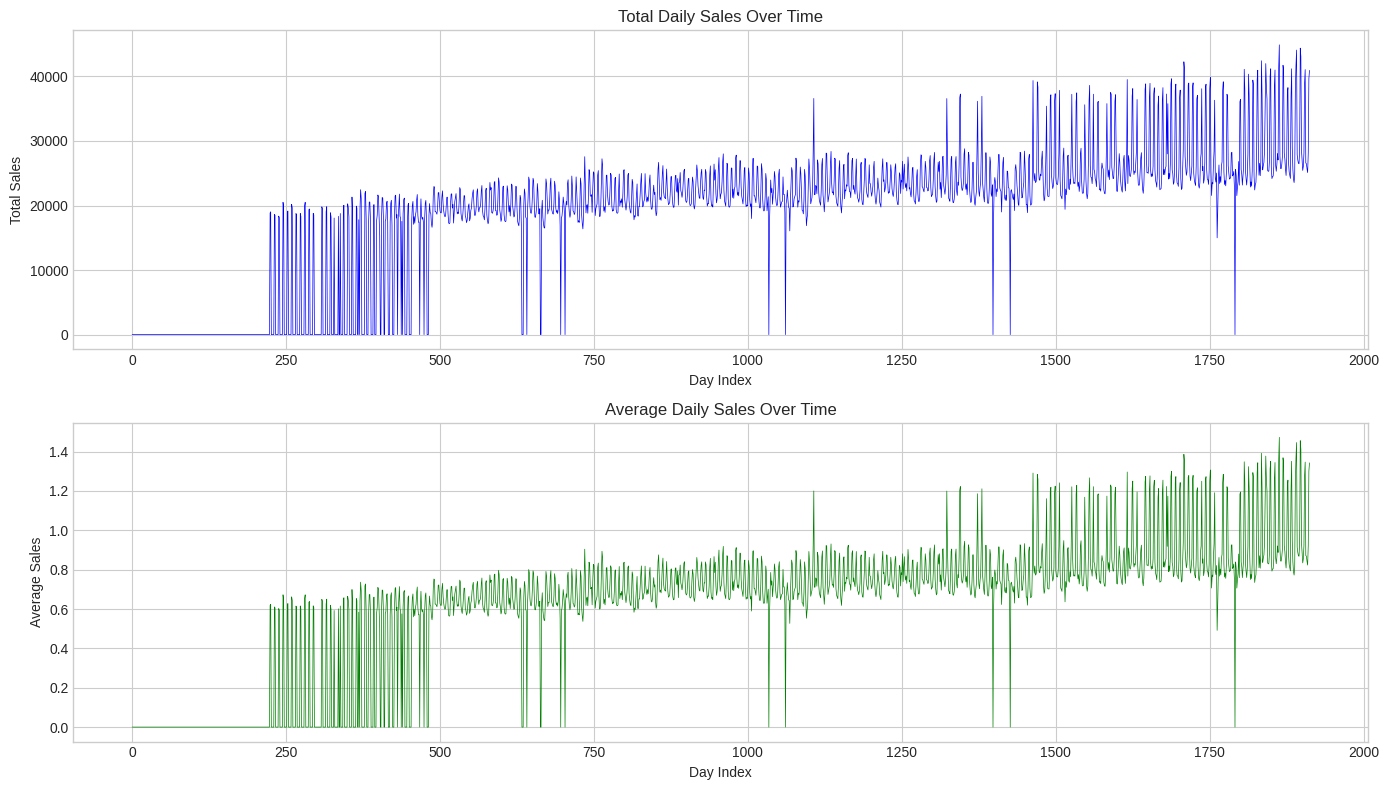

In [24]:
# 5.2 Time series visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Daily total sales
daily_total = sales_val_cleaned[day_cols].sum()
axes[0].plot(range(len(daily_total)), daily_total.values, color='blue', linewidth=0.5)
axes[0].set_xlabel('Day Index')
axes[0].set_ylabel('Total Sales')
axes[0].set_title('Total Daily Sales Over Time')

# Daily average sales
daily_avg = sales_val_cleaned[day_cols].mean()
axes[1].plot(range(len(daily_avg)), daily_avg.values, color='green', linewidth=0.5)
axes[1].set_xlabel('Day Index')
axes[1].set_ylabel('Average Sales')
axes[1].set_title('Average Daily Sales Over Time')

plt.tight_layout()
plt.savefig('sales_val_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


### SECTION 6: KEY METRICS FROM PREPROCESSED DATA

In [25]:
metrics = {
    'Total Item-Store Combinations': len(sales_val_cleaned),
    'Number of Days': len(day_cols),
    'Number of Categories': sales_val_cleaned['cat_id'].nunique(),
    'Number of Departments': sales_val_cleaned['dept_id'].nunique(),
    'Number of Items': sales_val_cleaned['item_id'].nunique(),
    'Number of Stores': sales_val_cleaned['store_id'].nunique(),
    'Number of States': sales_val_cleaned['state_id'].nunique(),
    'Total Sales': int(sales_val_cleaned['total_sales'].sum()),
    'Average Total Sales per Item-Store': f"{sales_val_cleaned['total_sales'].mean():.2f}",
    'Average Zero Ratio': f"{sales_val_cleaned['zero_ratio'].mean():.4f}",
    'Median Zero Ratio': f"{sales_val_cleaned['zero_ratio'].median():.4f}",
    'Items with >90% Zero Sales': (sales_val_cleaned['zero_ratio'] > 0.9).sum(),
    'Items with <10% Zero Sales': (sales_val_cleaned['zero_ratio'] < 0.1).sum()
}

print("\n--- Summary Metrics ---")
for key, value in metrics.items():
    print(f"  {key}: {value}")


--- Summary Metrics ---
  Total Item-Store Combinations: 30490
  Number of Days: 1913
  Number of Categories: 3
  Number of Departments: 3
  Number of Items: 824
  Number of Stores: 4
  Number of States: 3
  Total Sales: 65695409
  Average Total Sales per Item-Store: 2154.65
  Average Zero Ratio: 0.6820
  Median Zero Ratio: 0.7355
  Items with >90% Zero Sales: 5284
  Items with <10% Zero Sales: 353


In [26]:
# Save cleaned dataset
sales_val_cleaned.to_csv('/content/drive/MyDrive/IRP/M5 Forecasting dataset/sales_val_cleaned.csv', index=False)
print("\n✅ Cleaned sales validation dataset saved!")


✅ Cleaned sales validation dataset saved!


### SECTION 7: HALLUCINATION DETECTION

In [27]:
def detect_sales_hallucinations(df, day_cols):
    """Detect potential hallucinations/data quality issues"""
    hallucinations = {'entity': [], 'numeric': [], 'causal': []}

    # Entity checks
    print("\n1. ENTITY CHECKS")
    print("-" * 40)

    # ID format
    invalid_ids = df[~df['id'].str.match(r'^[A-Z]+_\d+_\d+_[A-Z]{2}_\d+_validation$')]
    if len(invalid_ids) > 0:
        hallucinations['entity'].append({'type': 'invalid_id', 'count': len(invalid_ids)})
        print(f"  ⚠️ {len(invalid_ids)} invalid IDs")
    else:
        print("  ✅ All IDs have valid format")

    # Duplicate IDs
    duplicates = df['id'].duplicated().sum()
    if duplicates > 0:
        hallucinations['entity'].append({'type': 'duplicate_ids', 'count': duplicates})
        print(f"  ⚠️ {duplicates} duplicate IDs")
    else:
        print("  ✅ No duplicate IDs")

    # Numeric checks
    print("\n2. NUMERIC CHECKS")
    print("-" * 40)

    all_sales = df[day_cols].values.flatten()

    # Negative sales
    negative = np.sum(all_sales < 0)
    if negative > 0:
        hallucinations['numeric'].append({'type': 'negative_sales', 'count': negative})
        print(f"  ⚠️ {negative} negative sales")
    else:
        print("  ✅ No negative sales")

    # Non-integer sales
    non_integer = np.sum(all_sales % 1 != 0)
    if non_integer > 0:
        hallucinations['numeric'].append({'type': 'non_integer_sales', 'count': non_integer})
        print(f"  ⚠️ {non_integer} non-integer sales")
    else:
        print("  ✅ All sales are integers")

    # Causal checks
    print("\n3. CAUSAL CHECKS")
    print("-" * 40)

    # Department sales patterns
    dept_sales = df.groupby('dept_id')['total_sales'].mean()
    print(f"  Average sales by department: {dept_sales.to_dict()}")

    return hallucinations

sales_val_hallucinations = detect_sales_hallucinations(sales_val_cleaned, day_cols)


1. ENTITY CHECKS
----------------------------------------
  ✅ All IDs have valid format
  ✅ No duplicate IDs

2. NUMERIC CHECKS
----------------------------------------
  ✅ No negative sales
  ✅ All sales are integers

3. CAUSAL CHECKS
----------------------------------------
  Average sales by department: {'1': 1905.9301546391753, '2': 1048.8047080979284, '3': 3933.4235722964763}


In [29]:
# Summary

print(f"\nFinal shape: {sales_val_cleaned.shape}")
print(f"Hallucinations detected: {sum(len(v) for v in sales_val_hallucinations.values())}")


Final shape: (30490, 1929)
Hallucinations detected: 0
